In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Tuple
import numpy as np

Array = np.ndarray


# ----------------------------
# 1) S行列をブロックとして扱う薄いラッパ
# ----------------------------
@dataclass(frozen=True)
class SBlock:
    """Multi-mode 2-port scattering matrix as 4 blocks.
    Port-1 has M modes, Port-2 has N modes.
    Shapes:
      S11: (M,M), S12:(M,N), S21:(N,M), S22:(N,N)
    """
    S11: Array
    S12: Array
    S21: Array
    S22: Array


def _diag_sqrt(d: Array) -> Array:
    # d is 1D positive diag entries
    return np.diag(np.sqrt(d))


def _diag_invsqrt(d: Array) -> Array:
    return np.diag(1.0 / np.sqrt(d))


# ----------------------------
# 2) 直線区間のS行列（論文 Eq.11-15）
# ----------------------------
def straight_section_s(gamma: Array, L: float) -> SBlock:
    """
    gamma: (K,) propagation constant for each mode (can be 1j*beta for lossless)
    L: section length
    Returns SBlock with same mode count on both ports (K modes each).
    """
    K = gamma.size
    phase = np.exp(-gamma * L)  # Eq.(15) style
    Z = np.zeros((K, K), dtype=complex)
    D = np.diag(phase.astype(complex))
    return SBlock(S11=Z, S12=D, S21=D, S22=Z)


# ----------------------------
# 3) 段差（接続）のS行列（論文 Appendix A-13〜A-16の形）
#    入力: P, R, Q （R,Qは対角行列だが実装では対角成分ベクトルで受ける）
# ----------------------------
def junction_s(P: Array, R_diag: Array, Q_diag: Array) -> SBlock:
    """
    P: overlap matrix between region-I and region-II modes over common aperture
       shape (M, N)  (region-I has M modes, region-II has N modes)
    R_diag: (M,)  R_mm = ∫ (e_I,m × h_I,m*)·z dS
    Q_diag: (N,)  Q_nn = ∫ (e_II,n × h_II,n*)·z dS
    """
    M, N = P.shape
    R = np.diag(R_diag.astype(float))
    Q = np.diag(Q_diag.astype(float))

    sqrtR = _diag_sqrt(R_diag)
    invsqrtR = _diag_invsqrt(R_diag)
    sqrtQ = _diag_sqrt(Q_diag)
    invsqrtQ = _diag_invsqrt(Q_diag)

    # Appendixの典型形：R±P P^T と Q±P^T P が出るブロック構造
    A = R + P @ P.T         # (M,M)
    B = Q + P.T @ P         # (N,N)

    A_inv = np.linalg.inv(A)
    B_inv = np.linalg.inv(B)

    S11 = sqrtR @ (A_inv @ (R - P @ P.T)) @ invsqrtR
    S12 = (2.0 * sqrtR) @ (A_inv @ P) @ invsqrtQ
    S21 = (2.0 * sqrtQ) @ (B_inv @ P.T) @ invsqrtR
    S22 = sqrtQ @ (B_inv @ (Q - P.T @ P)) @ invsqrtQ

    return SBlock(S11=S11, S12=S12, S21=S21, S22=S22)


# ----------------------------
# 4) カスケード（Redheffer star product）
#    Sa: ports (1)-(2), Sb: ports (2)-(3) を接続して、(1)-(3) を返す
# ----------------------------
def cascade(Sa: SBlock, Sb: SBlock) -> SBlock:
    """
    Multi-mode 2-port cascade. Internal port dimensions must match:
      Sa port-2 modes == Sb port-1 modes
    """
    # Dimensions
    M = Sa.S11.shape[0]               # external left
    K = Sa.S22.shape[0]               # internal
    K2 = Sb.S11.shape[0]
    N = Sb.S22.shape[0]               # external right
    if K != K2:
        raise ValueError(f"Internal port size mismatch: {K} vs {K2}")

    I = np.eye(K, dtype=complex)

    # D = inv(I - Sb11 * Sa22), F = inv(I - Sa22 * Sb11)
    D = np.linalg.inv(I - Sb.S11 @ Sa.S22)
    F = np.linalg.inv(I - Sa.S22 @ Sb.S11)

    S11 = Sa.S11 + Sa.S12 @ D @ Sb.S11 @ Sa.S21
    S12 = Sa.S12 @ D @ Sb.S12
    S21 = Sb.S21 @ F @ Sa.S21
    S22 = Sb.S22 + Sb.S21 @ F @ Sa.S22 @ Sb.S12

    return SBlock(S11=S11, S12=S12, S21=S21, S22=S22)


# ----------------------------
# 5) 便利: SBlock → 2Dフル行列化（デバッグ用）
# ----------------------------
def sblock_to_full(S: SBlock) -> Array:
    top = np.hstack([S.S11, S.S12])
    bot = np.hstack([S.S21, S.S22])
    return np.vstack([top, bot])


In [2]:
def z_cross_integrand(Ex: Array, Ey: Array, Hx: Array, Hy: Array) -> Array:
    """(E × H*)·z = Ex*Hy* - Ey*Hx*  だが、EとHは複素なのでHは共役を取る。"""
    return Ex * np.conj(Hy) - Ey * np.conj(Hx)


def overlap_RQ(
    Ex: Array, Ey: Array, Hx: Array, Hy: Array, w: Array
) -> complex:
    """∫ (E×H*)·z dS を数値積分。wは面積重み（dS相当）。"""
    return np.sum(z_cross_integrand(Ex, Ey, Hx, Hy) * w)


def build_overlap_matrices(
    # fields_I[m] = (Ex,Ey,Hx,Hy) on grid
    fields_I: Tuple[Tuple[Array, Array, Array, Array], ...],
    fields_II: Tuple[Tuple[Array, Array, Array, Array], ...],
    w: Array,
) -> Tuple[Array, Array, Array]:
    """
    returns:
      P (M,N), R_diag (M,), Q_diag (N,)
    """
    M = len(fields_I)
    N = len(fields_II)

    R_diag = np.zeros(M, dtype=float)
    Q_diag = np.zeros(N, dtype=float)
    P = np.zeros((M, N), dtype=complex)

    # R, Q
    for m in range(M):
        Ex, Ey, Hx, Hy = fields_I[m]
        R_diag[m] = np.real(overlap_RQ(Ex, Ey, Hx, Hy, w))
    for n in range(N):
        Ex, Ey, Hx, Hy = fields_II[n]
        Q_diag[n] = np.real(overlap_RQ(Ex, Ey, Hx, Hy, w))

    # P
    for m in range(M):
        Exm, Eym, Hxm, Hym = fields_I[m]
        for n in range(N):
            Exn, Eyn, Hxn, Hyn = fields_II[n]
            # P_mn = ∫ (e_I,m × h_II,n*)·z dS なので、EはI、HはII
            P[m, n] = np.sum(z_cross_integrand(Exm, Eym, Hxn, Hyn) * w)

    return P, R_diag, Q_diag


In [3]:
def device_smatrix(elements: list[SBlock]) -> SBlock:
    if not elements:
        raise ValueError("elements is empty")
    S = elements[0]
    for e in elements[1:]:
        S = cascade(S, e)
    return S


def return_loss_db(S11_scalar: complex) -> float:
    return -20.0 * np.log10(np.abs(S11_scalar))


C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:49: RuntimeWarning: divide by zero encountered in divide
  invsqrtR = np.diag(1.0 / np.sqrt(R_diag))
C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:51: RuntimeWarning: divide by zero encountered in divide
  invsqrtQ = np.diag(1.0 / np.sqrt(Q_diag))
C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:62: RuntimeWarning: invalid value encountered in matmul
  S11 = sqrtR @ (A_inv @ (R - P @ P.T)) @ invsqrtR
C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:63: RuntimeWarning: invalid value encountered in matmul
  S12 = (2.0 * sqrtR) @ (A_inv @ P) @ invsqrtQ
C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:64: RuntimeWarning: invalid value encountered in matmul
  S21 = (2.0 * sqrtQ) @ (B_inv @ P.T) @ invsqrtR
C:\Users\USER\AppData\Local\Temp\ipykernel_20436\4016010397.py:65: RuntimeWarning: invalid value encountered in matmul
  S22 = sqrtQ @ (B_inv @ (Q - P.T @ P)) @ invsqrt

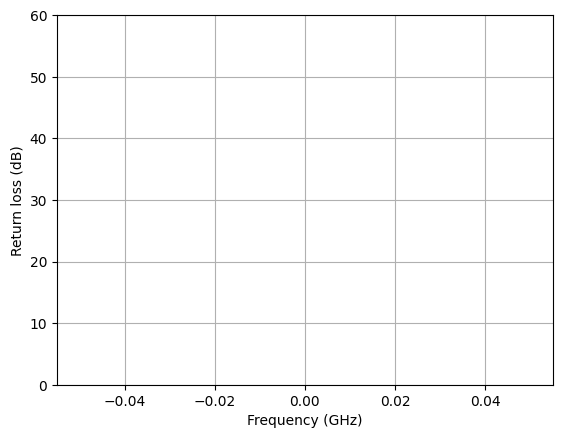

In [4]:
from __future__ import annotations

from dataclasses import dataclass
import numpy as np

# SciPyが入っている前提（普通は入っている）
from scipy.special import jv, jvp, jn_zeros, jnp_zeros

# ----------------------------
# 物理定数
# ----------------------------
c0 = 299_792_458.0
mu0 = 4e-7 * np.pi
eps0 = 1.0 / (mu0 * c0**2)

inch = 0.0254


# ----------------------------
# 2-port multi-mode S-matrix block
# ----------------------------
@dataclass(frozen=True)
class SBlock:
    S11: np.ndarray
    S12: np.ndarray
    S21: np.ndarray
    S22: np.ndarray


def straight_section_s(gamma: np.ndarray, L: float) -> SBlock:
    """論文の直線区間（ブロック対角で位相/減衰のみ）に対応。:contentReference[oaicite:3]{index=3}"""
    K = gamma.size
    phase = np.exp(-gamma * L).astype(complex)
    Z = np.zeros((K, K), dtype=complex)
    D = np.diag(phase)
    return SBlock(S11=Z, S12=D, S21=D, S22=Z)


def junction_s(P: np.ndarray, R_diag: np.ndarray, Q_diag: np.ndarray) -> SBlock:
    """
    段差（接続）のS行列。
    ここでは「R,Q,Pから作る標準的な形」を用いる（R,Qは数値積分で作る）。
    """
    M, N = P.shape
    R_diag = R_diag.astype(float)
    Q_diag = Q_diag.astype(float)

    sqrtR = np.diag(np.sqrt(R_diag))
    invsqrtR = np.diag(1.0 / np.sqrt(R_diag))
    sqrtQ = np.diag(np.sqrt(Q_diag))
    invsqrtQ = np.diag(1.0 / np.sqrt(Q_diag))

    R = np.diag(R_diag)
    Q = np.diag(Q_diag)

    A = R + P @ P.T
    B = Q + P.T @ P

    A_inv = np.linalg.inv(A)
    B_inv = np.linalg.inv(B)

    S11 = sqrtR @ (A_inv @ (R - P @ P.T)) @ invsqrtR
    S12 = (2.0 * sqrtR) @ (A_inv @ P) @ invsqrtQ
    S21 = (2.0 * sqrtQ) @ (B_inv @ P.T) @ invsqrtR
    S22 = sqrtQ @ (B_inv @ (Q - P.T @ P)) @ invsqrtQ

    return SBlock(S11=S11, S12=S12, S21=S21, S22=S22)


def cascade(Sa: SBlock, Sb: SBlock) -> SBlock:
    """Sa(1-2) と Sb(2-3) を接続して (1-3) を返す（Redheffer star product）。"""
    K = Sa.S22.shape[0]
    if Sb.S11.shape[0] != K:
        raise ValueError("Internal port mode count mismatch")

    I = np.eye(K, dtype=complex)

    D = np.linalg.inv(I - Sb.S11 @ Sa.S22)
    F = np.linalg.inv(I - Sa.S22 @ Sb.S11)

    S11 = Sa.S11 + Sa.S12 @ D @ Sb.S11 @ Sa.S21
    S12 = Sa.S12 @ D @ Sb.S12
    S21 = Sb.S21 @ F @ Sa.S21
    S22 = Sb.S22 + Sb.S21 @ F @ Sa.S22 @ Sb.S12
    return SBlock(S11=S11, S12=S12, S21=S21, S22=S22)


# ----------------------------
# 円形導波管：m=1のTE/TMモード列挙
# ----------------------------
def mode_list_circular_m1(total_modes: int):
    """
    モード順序：
      0: TE11
      1: TM11
      2: TE12
      3: TM12
      ...
    total_modes: TE+TM 合計個数
    """
    n_te = (total_modes + 1) // 2
    n_tm = total_modes // 2
    modes = []
    for n in range(1, max(n_te, n_tm) + 1):
        if n <= n_te:
            modes.append(("TE", n))
        if n <= n_tm:
            modes.append(("TM", n))
    return modes[:total_modes]


def cutoff_kc_circular(radius: float, modes):
    """
    kc = x/a
    TE: x = J1'(x)=0 の根（jnp_zeros）
    TM: x = J1(x)=0 の根（jn_zeros）
    """
    # 必要な最大nを拾う
    n_te = max([n for t, n in modes if t == "TE"] + [0])
    n_tm = max([n for t, n in modes if t == "TM"] + [0])

    te_roots = jnp_zeros(1, n_te) if n_te > 0 else np.array([])
    tm_roots = jn_zeros(1, n_tm) if n_tm > 0 else np.array([])

    kc = []
    for t, n in modes:
        if t == "TE":
            kc.append(te_roots[n - 1] / radius)
        else:
            kc.append(tm_roots[n - 1] / radius)
    return np.array(kc, dtype=float)


# ----------------------------
# 開口面グリッド（円内）を作る
# ----------------------------
def circle_grid(radius: float, n: int = 121):
    """
    [-a,a]x[-a,a] の正方格子を作り，円内点のみ採用する。
    戻り値は flatten 済み (Pts,) 配列。
    """
    x = np.linspace(-radius, radius, n)
    y = np.linspace(-radius, radius, n)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="xy")
    r = np.sqrt(X**2 + Y**2)
    mask = r <= radius

    Xf = X[mask].astype(float)
    Yf = Y[mask].astype(float)
    rf = r[mask].astype(float)
    phif = np.arctan2(Yf, Xf).astype(float)

    w = np.full_like(rf, dx * dx, dtype=float)  # 面積重み
    return rf, phif, w


# ----------------------------
# 円形導波管モードの横電磁界（m=1, cosφ偏波）
# ----------------------------
def fields_circular_mode_m1(
    mode_type: str,
    kc: float,
    beta: complex,
    omega: float,
    r: np.ndarray,
    phi: np.ndarray,
):
    """
    出力：Ex,Ey,Hx,Hy (Pts,)
    ここでは cos(phi) を基本にしたm=1の一偏波を用いる。
    """
    m = 1
    r_safe = np.where(r == 0.0, 1e-30, r)

    arg = kc * r
    J = jv(m, arg)
    dJ_dr = kc * jvp(m, arg, 1)  # d/dr J_m(kc r)

    cos_mphi = np.cos(m * phi)
    sin_mphi = np.sin(m * phi)

    if mode_type == "TE":
        # Hz = J * cos(phi)
        Hz = J * cos_mphi
        dHz_dr = dJ_dr * cos_mphi
        dHz_dphi = -m * J * sin_mphi

        Hr = 1j * beta / (kc**2) * dHz_dr
        Hphi = 1j * beta / (kc**2) * (1.0 / r_safe) * dHz_dphi

        Er = 1j * omega * mu0 / (kc**2) * (1.0 / r_safe) * dHz_dphi
        Ephi = -1j * omega * mu0 / (kc**2) * dHz_dr

    elif mode_type == "TM":
        # Ez = J * cos(phi)
        Ez = J * cos_mphi
        dEz_dr = dJ_dr * cos_mphi
        dEz_dphi = -m * J * sin_mphi

        Er = -1j * beta / (kc**2) * dEz_dr
        Ephi = -1j * beta / (kc**2) * (1.0 / r_safe) * dEz_dphi

        Hr = -1j * omega * eps0 / (kc**2) * (1.0 / r_safe) * dEz_dphi
        Hphi = 1j * omega * eps0 / (kc**2) * dEz_dr
    else:
        raise ValueError("mode_type must be 'TE' or 'TM'")

    # cylindrical -> cartesian
    c = np.cos(phi)
    s = np.sin(phi)

    Ex = Er * c - Ephi * s
    Ey = Er * s + Ephi * c
    Hx = Hr * c - Hphi * s
    Hy = Hr * s + Hphi * c

    return Ex, Ey, Hx, Hy


def section_fields(radius: float, modes, freq_hz: float, r: np.ndarray, phi: np.ndarray):
    """
    指定断面（半径radius）の全モードの Ex,Ey,Hx,Hy を (M,Pts) で返す。
    """
    omega = 2.0 * np.pi * freq_hz
    k0 = omega / c0

    kc = cutoff_kc_circular(radius, modes)  # (M,)
    # beta = sqrt(k0^2 - kc^2) （伝搬もエバネも複素sqrtで統一）
    beta = np.sqrt((k0**2 - kc**2).astype(complex))

    M = len(modes)
    Pts = r.size

    Ex = np.zeros((M, Pts), dtype=complex)
    Ey = np.zeros((M, Pts), dtype=complex)
    Hx = np.zeros((M, Pts), dtype=complex)
    Hy = np.zeros((M, Pts), dtype=complex)

    for i, (t, _n) in enumerate(modes):
        ex, ey, hx, hy = fields_circular_mode_m1(t, kc[i], beta[i], omega, r, phi)
        Ex[i, :] = ex
        Ey[i, :] = ey
        Hx[i, :] = hx
        Hy[i, :] = hy

    return Ex, Ey, Hx, Hy, beta


def overlaps_vectorized(ExI, EyI, HxI, HyI, ExII, EyII, HxII, HyII, w):
    """
    R_diag, Q_diag, P を高速に作る。
    integrand = Ex*conj(Hy) - Ey*conj(Hx)
    """
    # (M,)
    R_diag = np.real(np.sum((ExI * np.conj(HyI) - EyI * np.conj(HxI)) * w[None, :], axis=1))
    Q_diag = np.real(np.sum((ExII * np.conj(HyII) - EyII * np.conj(HxII)) * w[None, :], axis=1))

    # P: (M,N) = ∑ (ExI*conj(HyII) - EyI*conj(HxII)) w
    ExI_w = ExI * w[None, :]
    EyI_w = EyI * w[None, :]

    P = ExI_w @ np.conj(HyII).T - EyI_w @ np.conj(HxII).T
    return R_diag, Q_diag, P


# ----------------------------
# Fig.2 デバイスを組んでS11を掃引
# ----------------------------
def fig2_return_loss_db(
    freqs_ghz: np.ndarray,
    total_modes: int = 25,
    grid_n: int = 121,
):
    # Fig.2（図から読み取った）直径[in] と長さ[in]
    diam_in = np.array([1.369, 1.268, 1.136, 1.062, 1.039], dtype=float)
    L_in = np.array([0.584, 0.649, 0.770], dtype=float)

    radii = (diam_in * inch) / 2.0
    lengths = L_in * inch

    # 断面：r0 --(J0)-> r1 -L1- (J1)-> r2 -L2- (J2)-> r3 -L3- (J3)-> r4
    r0, r1, r2, r3, r4 = radii
    L1, L2, L3 = lengths

    modes = mode_list_circular_m1(total_modes)

    # 各段差の共通開口は「小さい方の断面」である（本文の前提）。:contentReference[oaicite:4]{index=4}
    # 今回は単調減少なので common は右側半径になる。
    grids = {
        "J0": circle_grid(r1, n=grid_n),
        "J1": circle_grid(r2, n=grid_n),
        "J2": circle_grid(r3, n=grid_n),
        "J3": circle_grid(r4, n=grid_n),
    }

    RL = np.zeros_like(freqs_ghz, dtype=float)

    for idx, fghz in enumerate(freqs_ghz):
        f = fghz * 1e9

        # --- Junction J0: r0 -> r1 (common r1)
        r, phi, w = grids["J0"]
        Ex0, Ey0, Hx0, Hy0, beta0 = section_fields(r0, modes, f, r, phi)
        Ex1, Ey1, Hx1, Hy1, beta1 = section_fields(r1, modes, f, r, phi)
        R0, Q1, P01 = overlaps_vectorized(Ex0, Ey0, Hx0, Hy0, Ex1, Ey1, Hx1, Hy1, w)
        SJ0 = junction_s(P01, R0, Q1)

        # --- Straight in r1
        gamma1 = 1j * beta1
        SS1 = straight_section_s(gamma1, L1)

        # --- Junction J1: r1 -> r2 (common r2)
        r, phi, w = grids["J1"]
        Ex1c, Ey1c, Hx1c, Hy1c, beta1c = section_fields(r1, modes, f, r, phi)
        Ex2, Ey2, Hx2, Hy2, beta2 = section_fields(r2, modes, f, r, phi)
        R1, Q2, P12 = overlaps_vectorized(Ex1c, Ey1c, Hx1c, Hy1c, Ex2, Ey2, Hx2, Hy2, w)
        SJ1 = junction_s(P12, R1, Q2)

        # --- Straight in r2
        gamma2 = 1j * beta2
        SS2 = straight_section_s(gamma2, L2)

        # --- Junction J2: r2 -> r3 (common r3)
        r, phi, w = grids["J2"]
        Ex2c, Ey2c, Hx2c, Hy2c, beta2c = section_fields(r2, modes, f, r, phi)
        Ex3, Ey3, Hx3, Hy3, beta3 = section_fields(r3, modes, f, r, phi)
        R2, Q3, P23 = overlaps_vectorized(Ex2c, Ey2c, Hx2c, Hy2c, Ex3, Ey3, Hx3, Hy3, w)
        SJ2 = junction_s(P23, R2, Q3)

        # --- Straight in r3
        gamma3 = 1j * beta3
        SS3 = straight_section_s(gamma3, L3)

        # --- Junction J3: r3 -> r4 (common r4)
        r, phi, w = grids["J3"]
        Ex3c, Ey3c, Hx3c, Hy3c, beta3c = section_fields(r3, modes, f, r, phi)
        Ex4, Ey4, Hx4, Hy4, beta4 = section_fields(r4, modes, f, r, phi)
        R3, Q4, P34 = overlaps_vectorized(Ex3c, Ey3c, Hx3c, Hy3c, Ex4, Ey4, Hx4, Hy4, w)
        SJ3 = junction_s(P34, R3, Q4)

        # --- Cascade all
        S = SJ0
        S = cascade(S, SS1)
        S = cascade(S, SJ1)
        S = cascade(S, SS2)
        S = cascade(S, SJ2)
        S = cascade(S, SS3)
        S = cascade(S, SJ3)

        # 入射は port1 の TE11（モード0）だけを想定 → reflection は S11[0,0]
        s11 = S.S11[0, 0]
        RL[idx] = -20.0 * np.log10(np.abs(s11))

    return RL


if __name__ == "__main__":
    freqs = np.linspace(7.0, 9.0, 81)  # GHz
    RL = fig2_return_loss_db(freqs, total_modes=25, grid_n=121)

    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(freqs, RL)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Return loss (dB)")
    plt.ylim(0, 60)
    plt.grid(True)
    plt.show()


In [5]:
freqs

array([7.   , 7.025, 7.05 , 7.075, 7.1  , 7.125, 7.15 , 7.175, 7.2  ,
       7.225, 7.25 , 7.275, 7.3  , 7.325, 7.35 , 7.375, 7.4  , 7.425,
       7.45 , 7.475, 7.5  , 7.525, 7.55 , 7.575, 7.6  , 7.625, 7.65 ,
       7.675, 7.7  , 7.725, 7.75 , 7.775, 7.8  , 7.825, 7.85 , 7.875,
       7.9  , 7.925, 7.95 , 7.975, 8.   , 8.025, 8.05 , 8.075, 8.1  ,
       8.125, 8.15 , 8.175, 8.2  , 8.225, 8.25 , 8.275, 8.3  , 8.325,
       8.35 , 8.375, 8.4  , 8.425, 8.45 , 8.475, 8.5  , 8.525, 8.55 ,
       8.575, 8.6  , 8.625, 8.65 , 8.675, 8.7  , 8.725, 8.75 , 8.775,
       8.8  , 8.825, 8.85 , 8.875, 8.9  , 8.925, 8.95 , 8.975, 9.   ])

In [6]:
RL

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan])